# 04 — Backtest and Comparison

Both regime signals are now fully causal. We now finally get to see if this extra complexity produces a tradeable edge over a trivial rule.

## Backtest mechanics

We take extreme care in preventing look-ahead bias by computing signals from today's close that cannot trade today's return 

Transaction costs are charged on turnover at 5 bps per unit.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.append('..')

from regime_utils import backtest, metrics, metrics_header

df = pd.read_pickle("data/features.pkl")
bt = pd.read_pickle("data/baselines.pkl")
probs_hmm = np.load("data/probs_hmm_wf.npy")
signal_wass = pd.read_pickle("data/signal_wass_wf.pkl")

bt["p_stress"] = probs_hmm[:, 1]
bt["cluster_w"] = signal_wass
bt = bt.dropna(subset=["p_stress", "cluster_w"])
print(f"Backtest period: {bt.index[0].date()} to {bt.index[-1].date()} ({len(bt)} days)")

Backtest period: 2010-03-01 to 2024-12-31 (3736 days)


## Two ways to translate a signal into a position

This turned out to matter more than expected, so both are tested:

- **Continuous** — `exposure = 1 − P(stress)`. Scales smoothly; degrades gracefully when the
  model is uncertain.
- **Binary** — `exposure = 0.5 if stress else 1.0`. Acts only when the signal is decisive.

Comparing the HMM (continuous) against Wasserstein (binary) would confound the *signal* with
the *rule*. Both signals are therefore evaluated under the binary rule.

In [7]:
bt["expo_hmm_cont"] = 1 - bt["p_stress"]
bt["expo_hmm_bin"]  = np.where(bt["p_stress"] > 0.5, 0.5, 1.0)
bt["expo_wass"]     = np.where(bt["cluster_w"] > 0, 0.5, 1.0)

for n in ["bh", "vol", "hmm_cont", "hmm_bin", "wass"]:
    bt[f"ret_{n}"] = backtest(bt[f"expo_{n}"], bt["ret"])

metrics_header()
metrics(bt["ret_bh"],       "Buy & Hold")
metrics(bt["ret_vol"],      "Vol target (baseline)")
metrics(bt["ret_hmm_cont"], "HMM (continuous)")
metrics(bt["ret_hmm_bin"],  "HMM (binary)")
metrics(bt["ret_wass"],     "Wasserstein (binary)")

print()
for n in ["vol", "hmm_cont", "hmm_bin", "wass"]:
    to = bt[f"expo_{n}"].diff().abs().sum() / (len(bt) / 252)
    print(f"Annual turnover {n:10}: {to:.1f}x")

Strategy               |    CAGR |     Vol | Sharpe |    MaxDD
--------------------------------------------------------------------
Buy & Hold             |  12.25% |  17.11% |   0.72 |  -35.75%
Vol target (baseline)  |   9.55% |  11.52% |   0.83 |  -19.21%
HMM (continuous)       |   7.07% |  10.24% |   0.69 |  -22.39%
HMM (binary)           |   9.76% |  12.39% |   0.79 |  -21.34%
Wasserstein (binary)   |  10.23% |  12.24% |   0.84 |  -19.98%

Annual turnover vol       : 3.0x
Annual turnover hmm_cont  : 4.2x
Annual turnover hmm_bin   : 2.0x
Annual turnover wass      : 3.5x


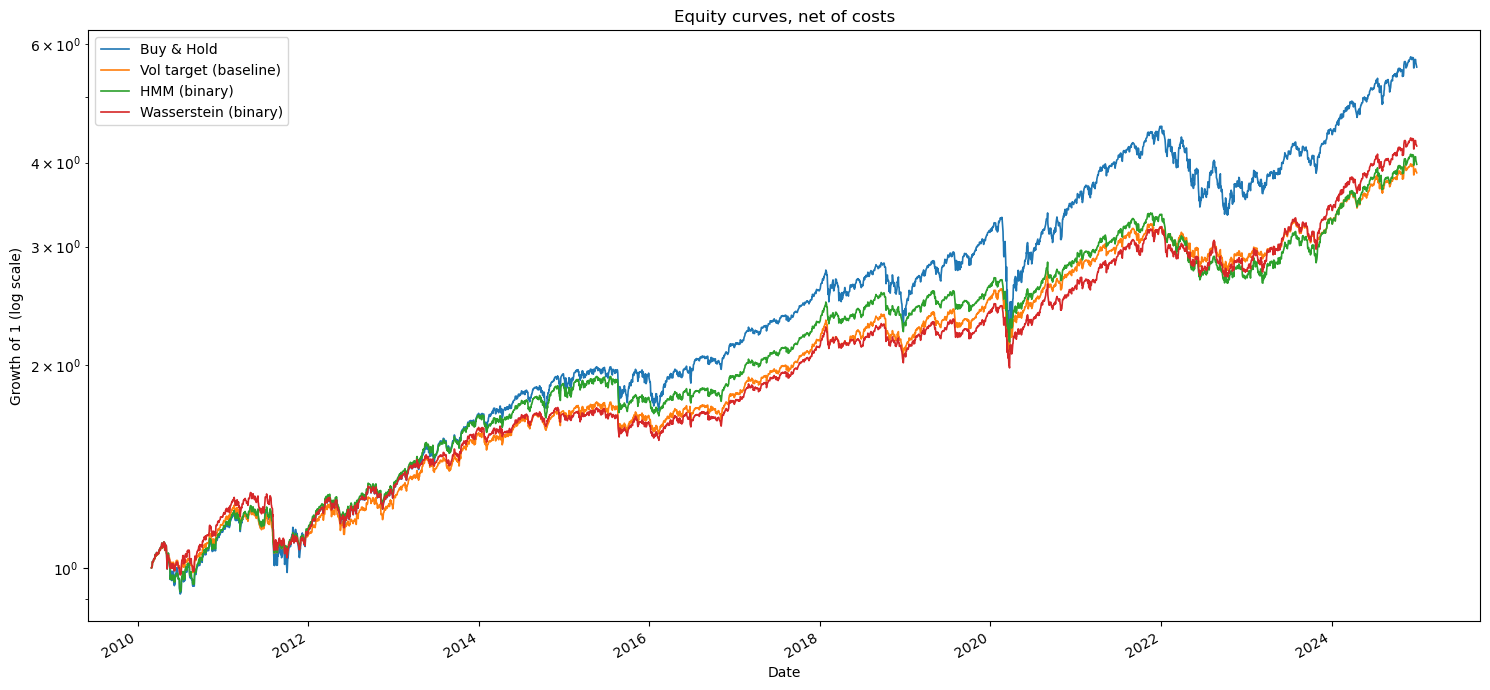

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))
for n, label in [("bh", "Buy & Hold"), ("vol", "Vol target (baseline)"),
                 ("hmm_bin", "HMM (binary)"), ("wass", "Wasserstein (binary)")]:
    (1 + bt[f"ret_{n}"].fillna(0)).cumprod().plot(ax=ax, label=label, lw=1.2)
ax.set_yscale("log"); ax.set_ylabel("Growth of 1 (log scale)")
ax.set_title("Equity curves, net of costs")
ax.legend()
plt.tight_layout(); plt.show()

## Findings

### 1. The exposure rule mattered more than the model

The same HMM signal, with no change to the model whatsoever, moves from **Sharpe 0.69**
(continuous exposure) to **0.79** (binary). 

The likely mechanism: `1 − P(stress)` reduces exposure *continuously* — any non-zero
probability pulls capital out of a market that drifts upward over time. The binary rule stays
fully invested unless the signal is decisive.

The next steps would be to test how a signal
becomes a position, how it can dominate the choice
of model.

### 2. Both methods beat the baseline — but only under the right rule

Under the binary rule, both HMM (0.79) and WK-means (0.84) beat realised-volatility targeting
(0.74). Under the continuous rule the HMM (0.69) loses to it. The headline "does regime
detection add value?" has no answer independent of the exposure rule.

### 3. Wasserstein edges out the HMM — but the margin is not conclusive

0.84 vs 0.79, with a better drawdown (−19.98% vs −21.34%) and lower turnover. The direction
is consistent with the non-parametric argument. But 0.05 of Sharpe over 15 years of a single
asset is not statistically decisive. We can honestly say that in this experiment WK-means scored
slightly higher, but not WK-means is superior.
